# Урок 10. Оптимизация: от GD до Adam

> **Зачем это нужно:** обучение нейросети — это запуск оптимизатора. От выбора оптимизатора и learning rate зависит, обучится ли модель за час или не обучится никогда. Это инженерный навык.

---

## 1. Постановка задачи

Дана функция `L(θ)`. Найти:

$$ \hat\theta = \arg\min_\theta L(\theta) $$

В ML `L` — функция потерь, `θ` — веса модели. Минимум обычно недоступен аналитически (нейросеть). Поэтому ищем итеративно.

---

## 2. Gradient Descent

Базовая формула:

$$ \theta_{t+1} = \theta_t - \eta \nabla L(\theta_t) $$

`η` — learning rate. Слишком большой — расходится, слишком маленький — учится вечность.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def gradient_descent(grad, x0, lr=0.1, steps=1000):
    x = x0.copy()
    for _ in range(steps):
        x -= lr * grad(x)
    return x


---
## 3. Stochastic Gradient Descent (SGD)

Полный градиент по всей выборке считать дорого. Берём градиент по одному примеру или мини-батчу:

$$ \theta_{t+1} = \theta_t - \eta \nabla L_i(\theta_t) $$

**Плюсы:** быстро, шум помогает выбираться из плохих локальных минимумов.

**Минусы:** траектория шумная, нужен правильный lr.

In [2]:
def sgd(loss_grad_one, X, y, w, lr=0.01, epochs=10):
    n = len(X)
    for _ in range(epochs):
        idx = np.random.permutation(n) # стохастичность (случайность)
        
        for i in idx:
            w -= lr * loss_grad_one(X[i], y[i], w)
    return w


def mini_batch_sgd(loss_grad_batch, X, y, w, lr=0.01, epochs=10, batch_size=32):
    n = len(X)
    for _ in range(epochs):
        idx = np.random.permutation(n)

        for i in range(0, n, batch_size):
            batch_idx = idx[i : i + batch_size]
            X_batch = X[batch_idx]
            y_batch = y[batch_idx]

            w -= lr * loss_grad_batch(X_batch, y_batch, w)
    return w

---

## 4. Momentum

GD «зигзагит» в оврагах. Момент добавляет инерцию:

$$ v_{t+1} = \beta v_t + (1 - \beta) \nabla L $$
$$ \theta_{t+1} = \theta_t - \eta v_{t+1} $$

Обычно $β = 0.9$ -  коэффициент затухания (трения). Показывает, какую часть прошлой скорости мы сохраняем. Если $β = 0$, алгоритм превращается в обычный SGD.

Обычный SGD ужасно ведет себя в так называемых «оврагах» (ravines). Это зоны, где в одну сторону (поперек оврага) склон очень крутой, а в другую (вдоль оврага, к реальному минимуму) — почти плоский.

SGD с Momentum гасит эти перпендикулярные колебания. Так как прыжки идут в противоположные стороны, они гасят скорость друг друга. А движение вперед вдоль оврага постоянно сонаправлено, поэтому скорость в этом направлении накапливается, и алгоритм буквально пролетает по дну оврага прямо к цели.

---

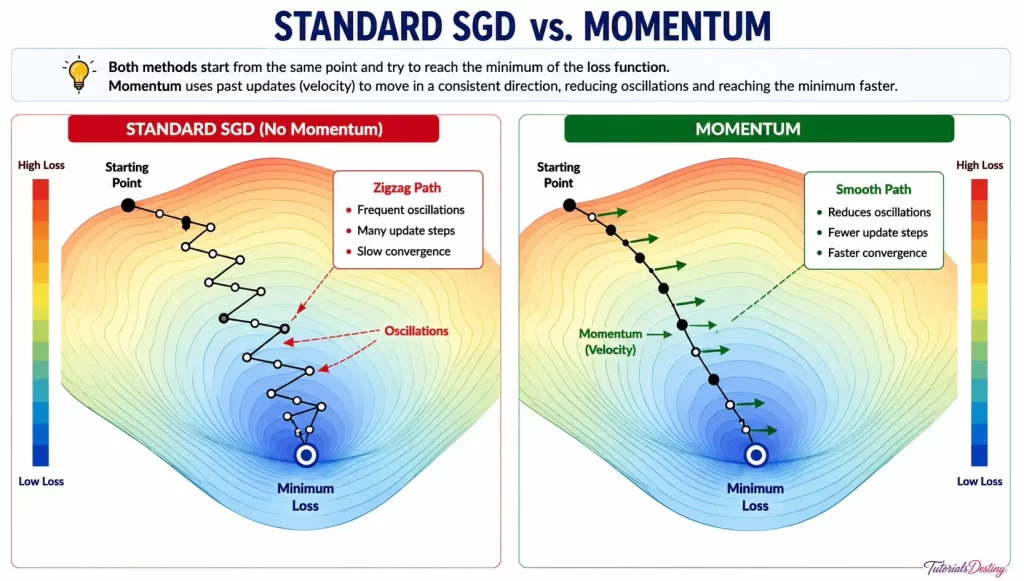

---

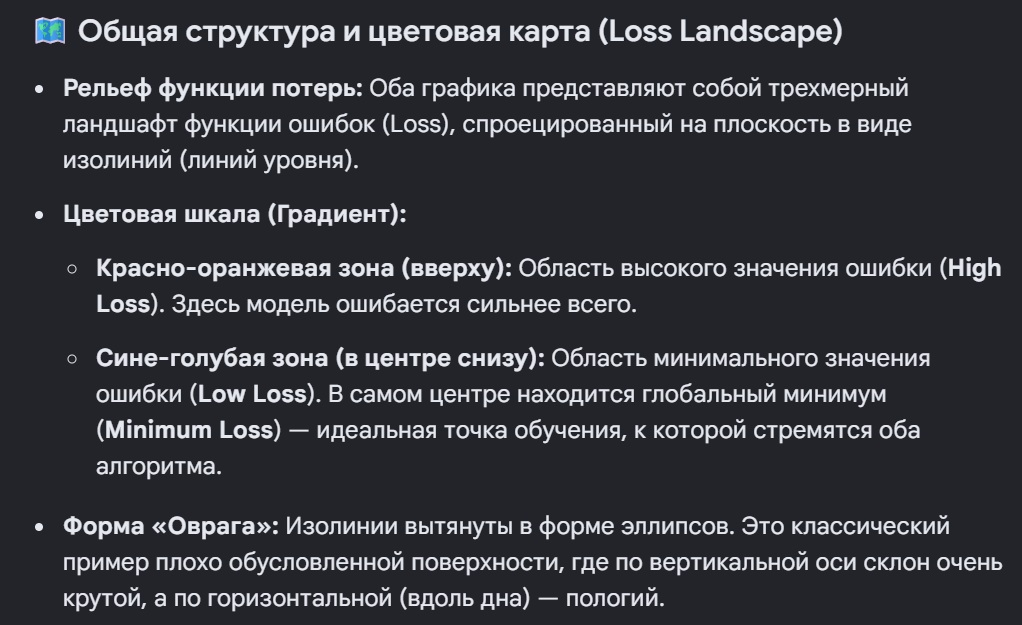
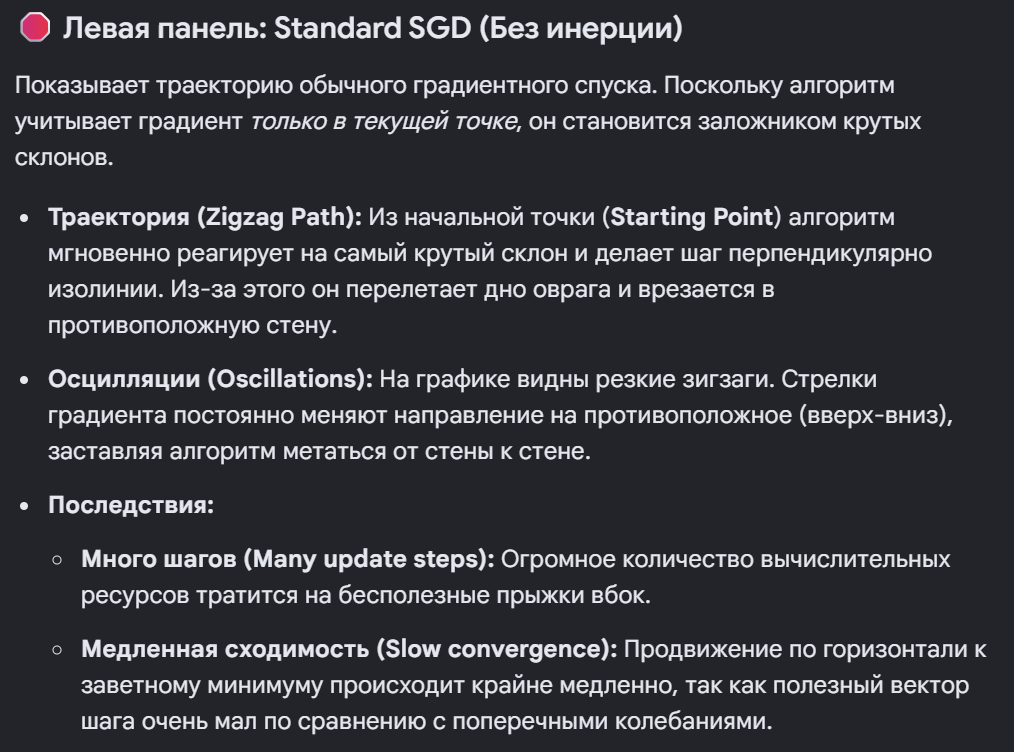
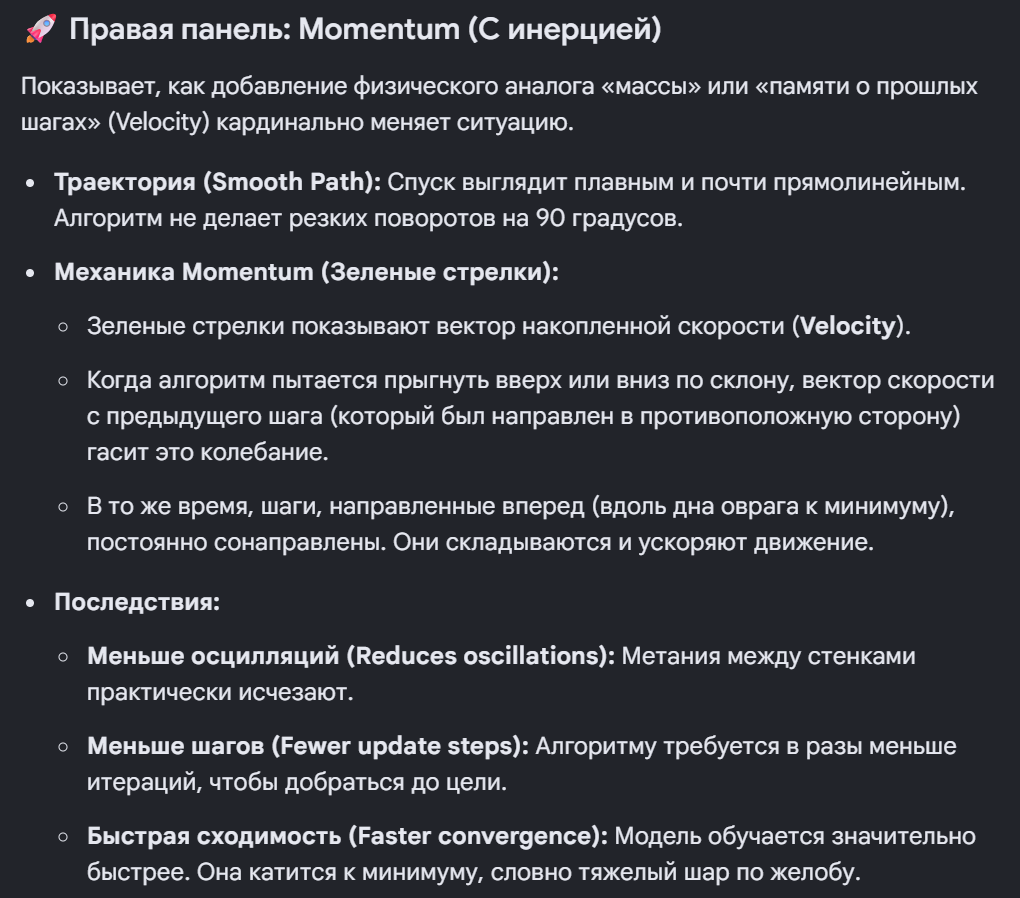

---

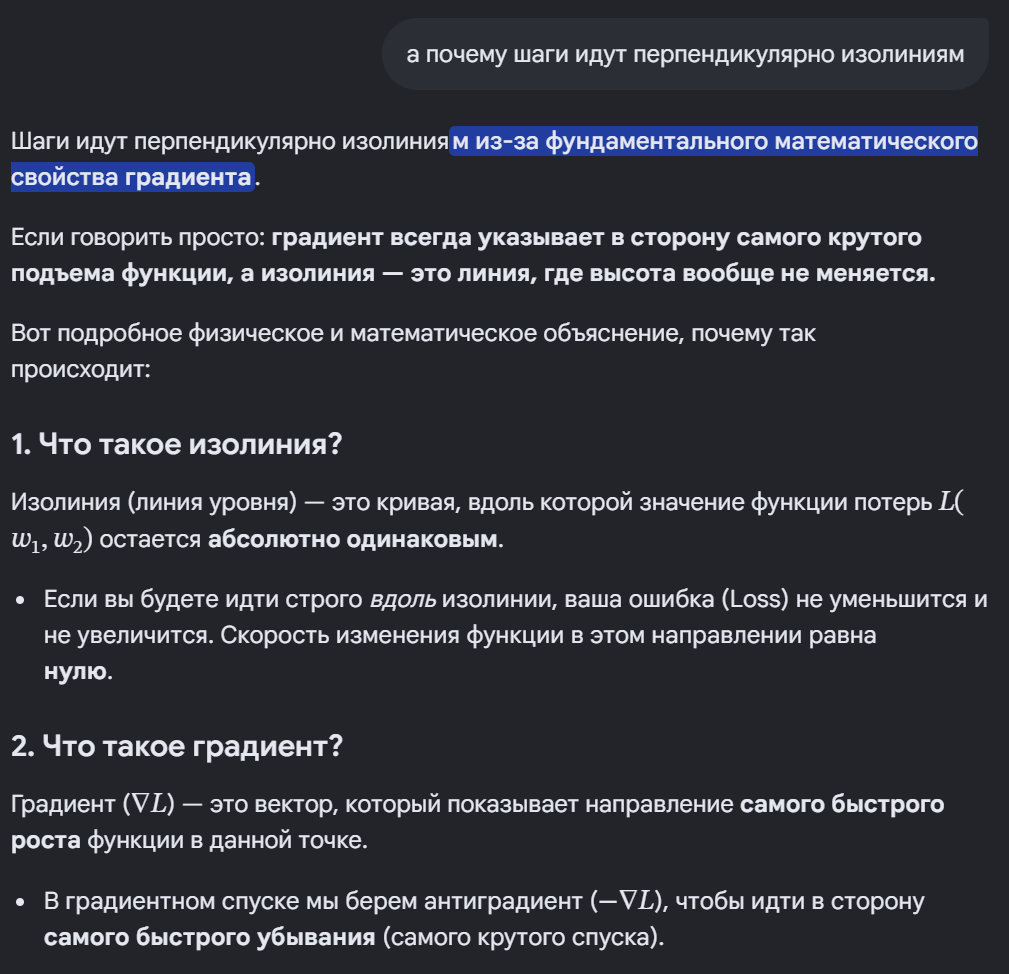
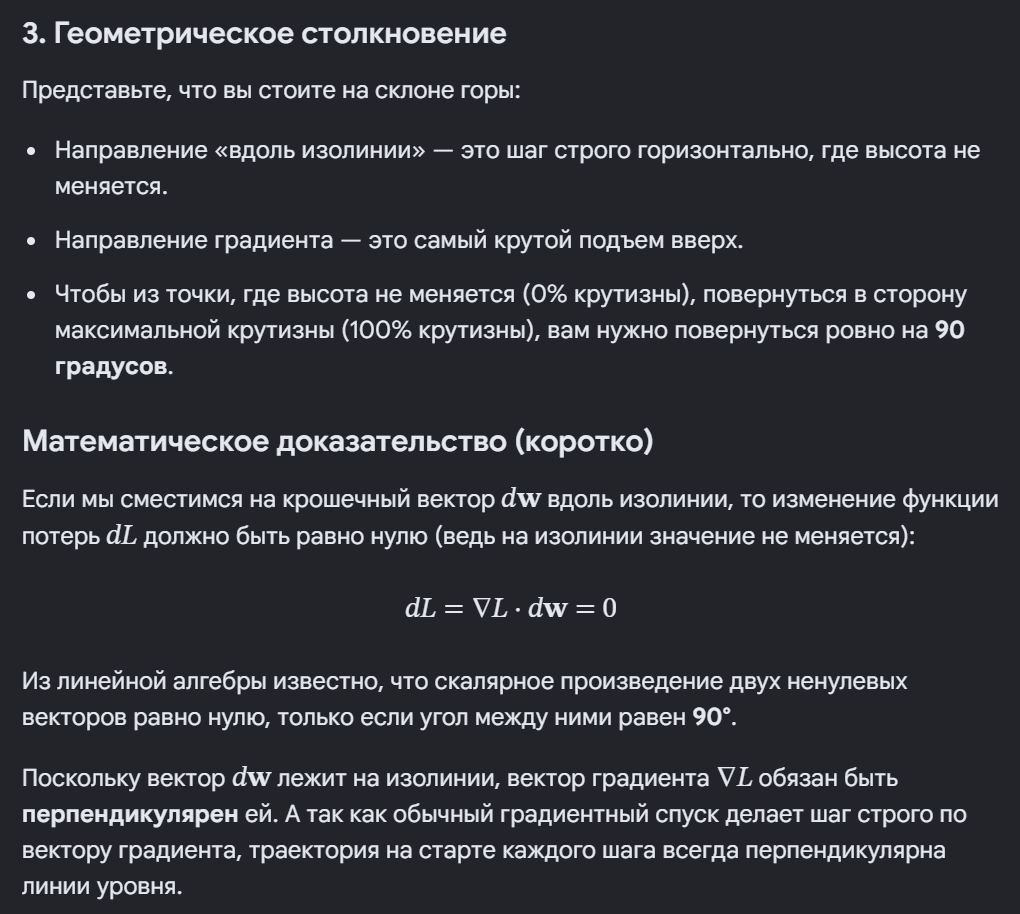

---
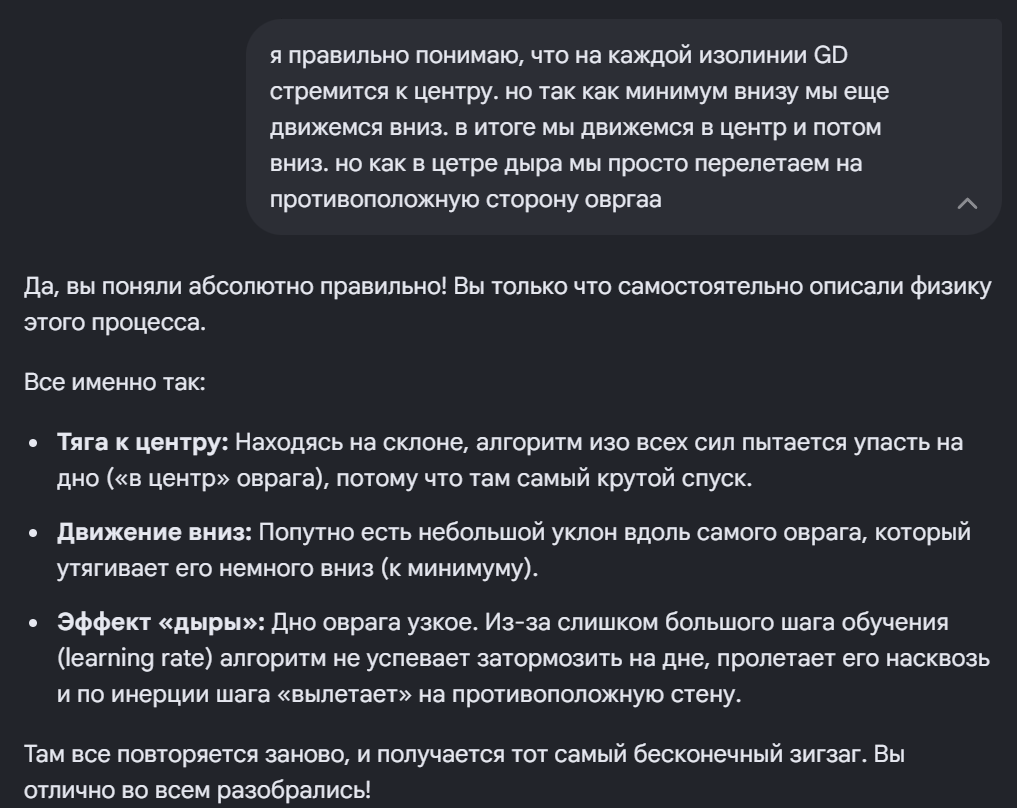

---
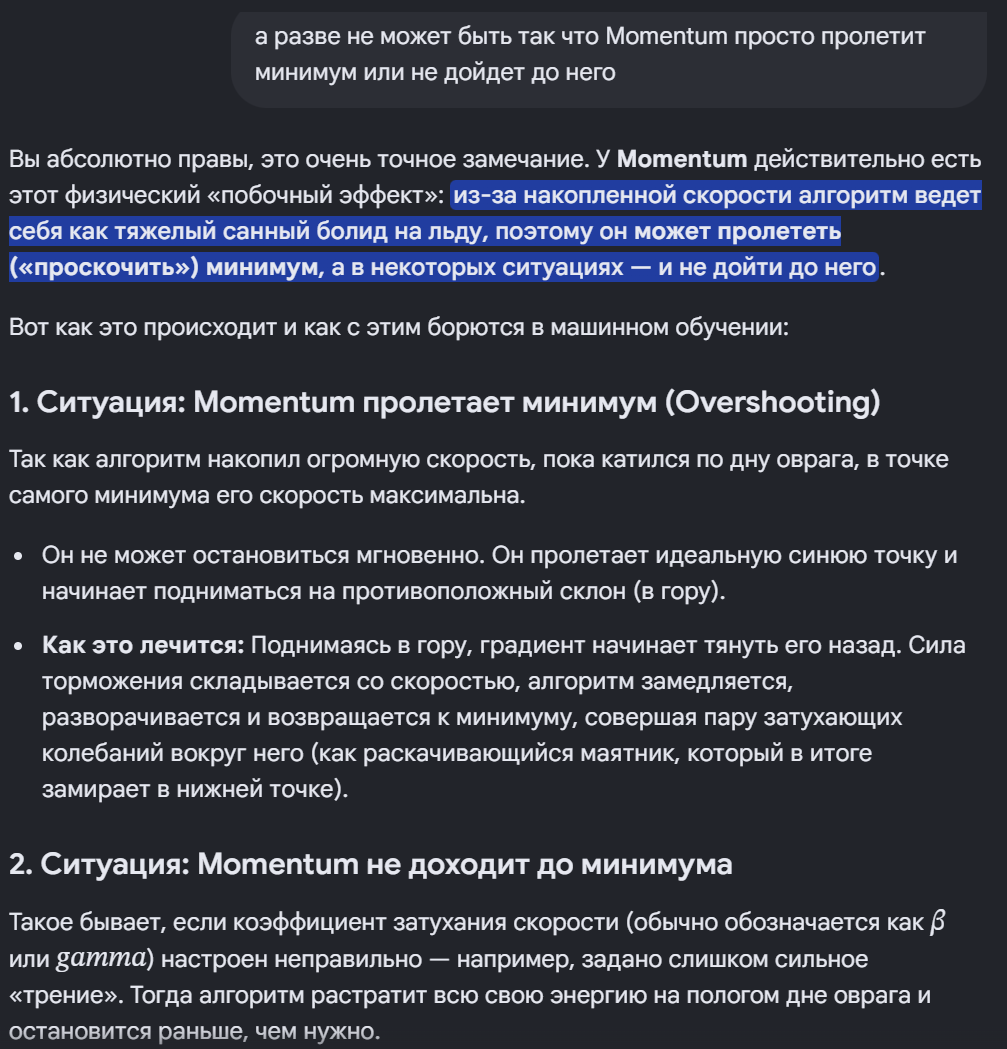

In [3]:
def momentum_gradient_descent(grad_f, w0, lr=0.1, beta=0.9, steps=100):
    w = np.array(w0, dtype=float)
    v = np.zeros_like(w)
    history = [w.copy()]

    for _ in range(steps):
        v = beta * v + lr * grad_f(w)
        w = w - v
        history.append(w.copy())

    return history


---
## 5. Метод оптимизации RMSProp (Root Mean Squared Propagation)

**RMSProp** — это адаптивный алгоритм градиентного спуска, который решает проблему «оврагов» функции потерь. Вместо одного фиксированного шага для всех параметров, он автоматически **уменьшает** скорость обучения для крутых склонов и **увеличивает** для пологих направлений.


### Математические формулы

На каждом шаге $t$ для каждого веса $w$ алгоритм выполняет два действия:

1. **Обновление скользящего среднего квадратов градиентов:**
$$v_t = \beta \cdot v_{t-1} + (1 - \beta) \cdot g_t^2$$

2. **Обновление весов модели с адаптивным шагом:**
$$w_{t+1} = w_t - \frac{\eta}{\sqrt{v_t} + \epsilon} \cdot g_t$$

* где $g_t$ — текущий градиент, $\eta$ — базовый learning rate, $\beta$ — коэффициент памяти (обычно $0.9$), а $\epsilon$ ($10^{-8}$) защищает от деления на ноль.

---



In [4]:
def rmsprop(grad_f, w0, lr=0.01, beta=0.9, eps=1e-8, steps=1000):
    w = np.array(w0, dtype=float)
    v = np.zeros_like(w)
    history = [w.copy()]

    for _ in range(steps):
        grad = grad_f(w)
        v = beta * v + (1 - beta) * (grad ** 2)
        w = w - (lr / (np.sqrt(v) + eps)) * grad
        history.append(w.copy())
    return history

---
## 6. Метод оптимизации Adam (Adaptive Moment Estimation)

**Adam** — это адаптивный алгоритм, сочетающий в себе идею накопления инерции из **Momentum** и идею индивидуального масштабирования шагов из **RMSProp**.

---

### Математические формулы

На каждом шаге $t$ для каждого веса $w$ алгоритм вычисляет два «момента» (отсюда и название):

1. **Вычисление скользящего среднего градиентов (Первый момент / Инерция из Momentum):**
$$m_t = \beta_1 \cdot m_{t-1} + (1 - \beta_1) \cdot g_t$$

2. **Вычисление скользящего среднего квадратов градиентов (Второй момент / Крутизна из RMSProp):**
$$v_t = \beta_2 \cdot v_{t-1} + (1 - \beta_2) \cdot g_t^2$$

3. **Коррекция смещения (Bias Correction):**
На первых шагах значения $m_t$ и $v_t$ сильно занижены, так как они стартуют с нулей. Алгоритм исправляет это математически:
$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$

4. **Обновление весов модели:**
$$w_{t+1} = w_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \cdot \hat{m}_t$$

* **Параметры по умолчанию (промышленный стандарт):**
  * $\eta$ (learning rate) = $0.001$
  * $\beta_1$ (отвечает за инерцию) = $0.9$
  * $\beta_2$ (отвечает за адаптацию шага) = $0.999$
  * $\epsilon$ (защита от деления на ноль) = $10^{-8}$

---


In [5]:
def adam(grad, w0, lr=1e-3, b1=0.9, b2=0.999, eps=1e-8, n_steps=1000):
    w = w0.copy()
    m, v = np.zeros_like(w), np.zeros_like(w)
    for t in range(1, n_steps+1):
        g = grad(w)
        m = b1 * m + (1 - b1) * g
        v = b2 * v + (1 - b2) * g**2
        m_hat = m / (1 - b1**t)
        v_hat = v / (1 - b2**t)
        w -= lr * m_hat / (np.sqrt(v_hat) + eps)
    return w

---
## 7. Learning Rate Scheduling (Расписания скорости обучения)

Хороший размер шага (`lr`) в начале обучения — плохой в конце. Стратегии планирования LR помогают автоматизировать изменение шага от эпохи к эпохе.

---

### 1. Step Decay (Шаговое затухание)
Периодически уменьшает `lr` на фиксированный коэффициент каждые несколько эпох.
* **Как работает:** График выглядит как ступенчатая лестница. Например, каждые 10 эпох мы умножаем текущий `lr` на `0.1`.
* **Минус:** Требует ручной настройки интервалов. Резкое падение шага может затормозить обучение, если оно произошло слишком рано.

### 2. Cosine Annealing (Косинусное затухание)
Плавно уменьшает скорость обучения, следуя траектории функции косинуса.
* **Формула:** На шаге $t$ из общего числа шагов $T$:
$$\eta_t = \eta_{min} + \frac{1}{2}(\eta_{max} - \eta_{min})\left(1 + \cos\left(\frac{T_{cur}}{T_{max}}\pi\right)\right)$$
* **Плюс:** Очень плавное снижение, которое отлично зарекомендовало себя при обучении современных CNN и Vision-трансформеров. Часто комбинируется с "перезапусками" (Restarts), когда LR снова резко поднимается вверх, чтобы выбить модель из локальных минимумов.

### 3. Warmup + Decay (Разгон + Затухание)
Особая стратегия, где обучение начинается с микроскопического `lr`, который линейно **растет** в первые несколько сотен шагов (эпох), а затем плавно затухает (линейно, по косинусу или экспоненте).
* **Зачем нужен Warmup:** В первые итерации градиенты в глубоких сетях (особенно в Трансформерах, BERT, GPT) могут быть гигантскими и нестабильными. Если сразу дать большой шаг, модель просто «взорвется» (NaN). Разгон стабилизирует веса на старте.
* **Применение:** Стандарт де-факто для всех Transformer-архитектур.

### 4. One-Cycle Policy (Одноцикловая политика)
Стратегия, предложенная Лесли Смитом и популяризированная библиотекой Fast.ai. Обучение делится на три фазы внутри одного цикла:
1. **Разгон:** `lr` агрессивно растет от минимума до пикового значения (первая треть обучения).
2. **Торможение:** `lr` плавно падает обратно до начального минимума (вторая треть обучения).
3. **Финальное затухание (Cooldown):** `lr` падает еще ниже, практически до нуля, для сверхтонкой финальной настройки (последняя треть).
* **Плюс:** Позволяет использовать экстремально большие пиковые шаги без риска взорвать модель, что сокращает время обучения в несколько раз (эффект "Суперконвергенции").

---

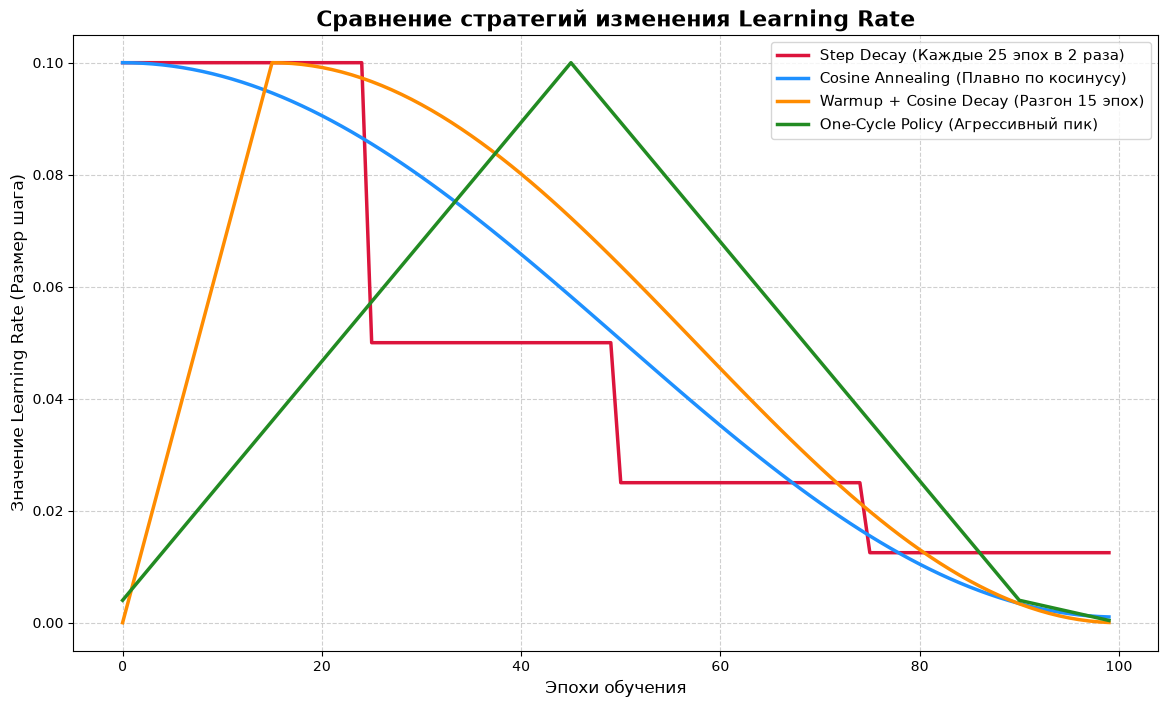

In [6]:
# Настройки симуляции
epochs = 100
init_lr = 0.1

# 1. Симуляция Step Decay
def get_step_decay(epochs, init_lr, step_size=25, gamma=0.5):
    lrs = []
    current_lr = init_lr
    for epoch in range(epochs):
        if epoch > 0 and epoch % step_size == 0:
            current_lr *= gamma
        lrs.append(current_lr)
    return lrs

# 2. Симуляция Cosine Annealing
def get_cosine_annealing(epochs, init_lr, eta_min=0.001):
    return [eta_min + 0.5 * (init_lr - eta_min) * (1 + np.cos(epoch / epochs * np.pi)) for epoch in range(epochs)]

# 3. Симуляция Warmup + Cosine Decay
def get_warmup_decay(epochs, init_lr, warmup_epochs=15):
    lrs = []
    for epoch in range(epochs):
        if epoch < warmup_epochs:
            # Линейный разгон от 0 до init_lr
            lr = (epoch / warmup_epochs) * init_lr
        else:
            # Косинусное затухание после warmup
            progress = (epoch - warmup_epochs) / (epochs - warmup_epochs)
            lr = 0.5 * init_lr * (1 + np.cos(progress * np.pi))
        lrs.append(lr)
    return lrs

# 4. Симуляция One-Cycle Policy
def get_one_cycle(epochs, max_lr=0.1, div_factor=25, final_div_factor=10000):
    lrs = []
    initial_lr = max_lr / div_factor
    final_lr = initial_lr / final_div_factor
    
    # Разделение на фазы: 45% разгон, 45% падение, 10% финальный допил
    phase1 = int(epochs * 0.45)
    phase2 = int(epochs * 0.45)
    phase3 = epochs - phase1 - phase2
    
    for epoch in range(epochs):
        if epoch < phase1:
            # Линейный рост до max_lr
            pct = epoch / phase1
            lr = initial_lr + (max_lr - initial_lr) * pct
        elif epoch < phase1 + phase2:
            # Линейное падение до initial_lr
            pct = (epoch - phase1) / phase2
            lr = max_lr - (max_lr - initial_lr) * pct
        else:
            # Финальное падение до абсолютного минимума
            pct = (epoch - phase1 - phase2) / phase3
            lr = initial_lr - (initial_lr - final_lr) * pct
        lrs.append(lr)
    return lrs


step_lrs = get_step_decay(epochs, init_lr)
cosine_lrs = get_cosine_annealing(epochs, init_lr)
warmup_lrs = get_warmup_decay(epochs, init_lr)
one_cycle_lrs = get_one_cycle(epochs, max_lr=init_lr)

plt.figure(figsize=(14, 8))
plt.plot(step_lrs, label='Step Decay (Каждые 25 эпох в 2 раза)', linewidth=2.5, color='crimson')
plt.plot(cosine_lrs, label='Cosine Annealing (Плавно по косинусу)', linewidth=2.5, color='dodgerblue')
plt.plot(warmup_lrs, label='Warmup + Cosine Decay (Разгон 15 эпох)', linewidth=2.5, color='darkorange')
plt.plot(one_cycle_lrs, label='One-Cycle Policy (Агрессивный пик)', linewidth=2.5, color='forestgreen')

plt.title('Сравнение стратегий изменения Learning Rate', fontsize=16, fontweight='bold')
plt.xlabel('Эпохи обучения', fontsize=12)
plt.ylabel('Значение Learning Rate (Размер шага)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11, loc='upper right')
plt.show()

---
## 8. Седловые точки и локальные минимумы в высоких размерностях
---

### 1. В высоких размерностях локальных минимумов меньше, чем кажется

Вектор весов современной нейросети имеет огромную размерность $N$. Чтобы критическая точка (где градиент равен нулю) оказалась **локальным минимумом**, функция потерь должна расти во всех возможных направлениях.

* **Математическая вероятность:** Представьте, что в случайной критической точке по каждому отдельному направлению функция может либо расти (минимум), либо убывать (максимум) с вероятностью 50/50.
* Чтобы точка стала истинным локальным минимумом, знаки кривизны по всем направлениям должны совпасть. Вероятность этого события равна:
  $$P(\text{локальный минимум}) \approx \left(\frac{1}{2}\right)^N$$
* Если $N = 1000$ (очень маленькая подсеть), эта вероятность стремится к абсолютному нулю. Подавляющее большинство критических точек, с которыми сталкивается оптимизатор — это **седловые точки** (по одним осям функция растет, а по другим — убывает).

---

### 2. Почему сёдла особенно неприятны

Седловая точка (Saddle Point) коварна тем, что в ней вектор градиента становится равен нулю ($\nabla L = 0$).

* Обычный градиентный спуск, попадая в окрестность седла, резко замедляется. Шаги стремятся к нулю.
* Модель может «застрять» на плоском плато седловой точки на сотни эпох. На графике обучения это выглядит как стагнация (loss не меняется), и инженеру может показаться, что модель сошлась, хотя она застряла на полпути.

---

### 3. Как шум SGD помогает выбираться из сёдел

Когда мы обучаем модель с помощью **Стохастического градиентного спуска (SGD)**, мы считаем градиент не по всему датасету, а по маленьким случайным подвыборкам (Mini-batches).

* Из-за случайности батчей, вычисленный градиент всегда немного "шумит" и колеблется вокруг истинного значения.
* Этот стохастический шум работает как **случайная встряска**.
* Когда алгоритм застревает на плоском седле, случайный шум подталкивает точку в разных направлениях. Рано или поздно эта встряска вытолкнет модель на тот склон седла, который ведет вниз.

---

### 4. Почему Adam лучше справляется с сёдлами

Чистый градиентный спуск (GD) в седловой точке бессилен, потому что шаг пропорционален величине градиента, а он равен нулю. **Adam** обходит эту ловушку за счет двух механизмов:

1. **Инерция (Momentum):** Если модель влетела в седловую точку на скорости, накопленный первый момент ($m_t$) за счет инерции протащит её сквозь плоское плато дальше, даже если текущий градиент в этой точке обнулился.
2. **Адаптивный шаг (RMSProp часть):** Вдоль осей, где градиент стал микроскопическим (на плоской части седла), значение второго момента ($v_t$) устремляется к нулю. Но в формуле Adam мы **делим на $\sqrt{v_t}$**. Деление на маленькое число автоматически **раздувает масштаб шага** по этой оси, помогая модели мгновенно сорваться с седла вниз.

---
---
---

## 9. Практические задания

1. **GD vs SGD vs Adam на параболе.** Минимизируйте `f(x, y) = x² + 100y²` всеми тремя. Постройте траектории на 2D. Кто быстрее доходит до минимума?


In [7]:
import numpy as np
import matplotlib.pyplot as plt

[-5.30121856e-02  3.38087328e-78]
[-0.51820654 -0.05825793]
[1.17109696e-07 1.50845747e-09]


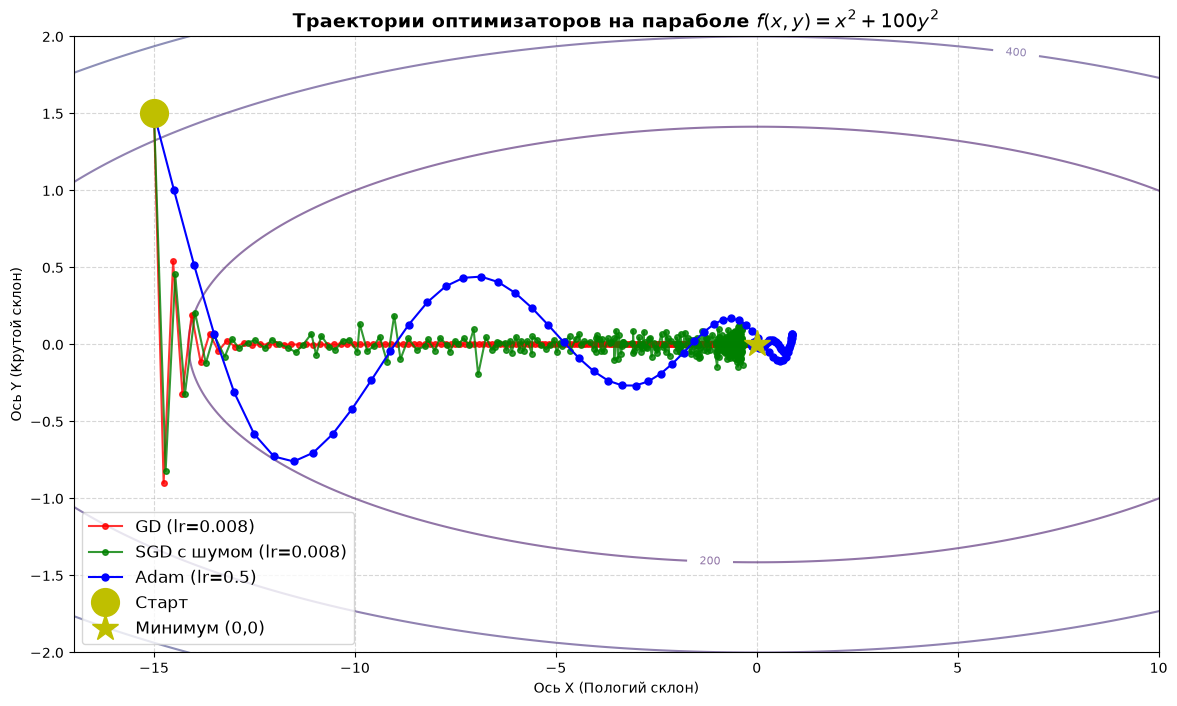

In [ ]:
# Мы минимизируем функцию f(x). Ищем ее минимум
#Цель алгоритма: Найти такие координаты (x, y), 
# при которых значение функции f(x, y) станет минимально возможным.

def L(w):
    return w[0] ** 2 + 100 * w[1] ** 2

def grad_f(w):
    return np.array([2.0 * w[0], 200.0 * w[1]])

# 1. Классический Gradient Descent (GD)
def gd(grad, w0, lr=0.1, steps=1000):
    w = np.array(w0, dtype=float)
    history = [w.copy()]
    for _ in range(steps):
        w -= lr * grad(w)
        history.append(w.copy())

    return w, np.array(history)

# 2. Stochastic Gradient Descent (SGD) с шумом мини-батчей
def sgd(grad, w0, lr=0.1, steps=1000, noise_level=5.0):
    w = np.array(w0, dtype=float)
    history = [w.copy()]
    for _ in range(steps):
        w -= lr * (grad(w) + np.random.normal(loc=0, scale=noise_level, size=w.shape))
        history.append(w.copy())

    return w, np.array(history)

# 3. Адаптивный метод Adam
def adam(grad, w0, lr=0.1, steps=1000, beta1=0.9, beta2=0.999, eps=1e-8):
    w = np.array(w0, dtype=float)
    m, v = np.zeros_like(w), np.zeros_like(w)
    history = [w.copy()]
    for t in range(1, steps):
        m = beta1 * m + (1.0 - beta1) * grad(w)
        v = beta2 * v + (1.0 - beta2) * (grad(w) ** 2)

        m_hat = m / (1.0 - beta1 ** t)
        v_hat = v / (1.0 - beta2 ** t)

        w -= (lr / (np.sqrt(v_hat) + eps)) * m_hat
        history.append(w.copy())
    return w, np.array(history)

start_point = [-15.0, 1.5]

w_gd, path_gd = gd(grad=grad_f, w0=start_point, lr=0.008, steps=350)
w_sgd, path_sgd = sgd(grad=grad_f, w0=start_point, lr=0.008, steps=350)
w_adam, path_adam = adam(grad=grad_f, w0=start_point, lr=0.5, steps=350)
print(w_gd)
print(w_sgd)
print(w_adam)

x = np.linspace(-20.0, 20.0, 500)
y = np.linspace(-5.0, 5.0, 500)
X, Y = np.meshgrid(x, y)
Z = X ** 2 + 100 * Y ** 2

plt.figure(figsize=(14, 8))
contours = plt.contour(X, Y, Z, levels=15, cmap='viridis', alpha=0.6)
plt.clabel(contours, inline=True, fontsize=8)

plt.plot(path_gd[:, 0], path_gd[:, 1], '-o', color='red', label='GD (lr=0.008)', markersize=4, alpha=0.8)
plt.plot(path_sgd[:, 0], path_sgd[:, 1], '-o', color='green', label='SGD с шумом (lr=0.008)', markersize=4, alpha=0.8)
plt.plot(path_adam[:, 0], path_adam[:, 1], '-o', color='blue', label='Adam (lr=0.5)', markersize=5)

plt.plot(start_point[0], start_point[1], 'yo', markersize=20, label='Старт')
plt.plot(0, 0, 'y*', markersize=20, label='Минимум (0,0)')

plt.title('Траектории оптимизаторов на параболе $f(x, y) = x^2 + 100y^2$', fontsize=14, fontweight='bold')
plt.xlabel('Ось X (Пологий склон)')
plt.ylabel('Ось Y (Крутой склон)')
plt.xlim(-17, 10)
plt.ylim(-2, 2)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.show()

---
2. **Розенброк.** Запустите все оптимизаторы на функции Розенброка из урока 04. Какой нашёл минимум? Какой застрял?

Функция Розенброка ("банановый овраг") — это классический бенчмарк для оптимизаторов: $f(x, y) = (1 - x)^2 + 100(y - x^2)^2$.
Её глобальный минимум находится в точке $(1, 1)$, внутри узкого, изогнутого и очень пологого дна оврага. Стенки оврага при этом экстремально крутые.


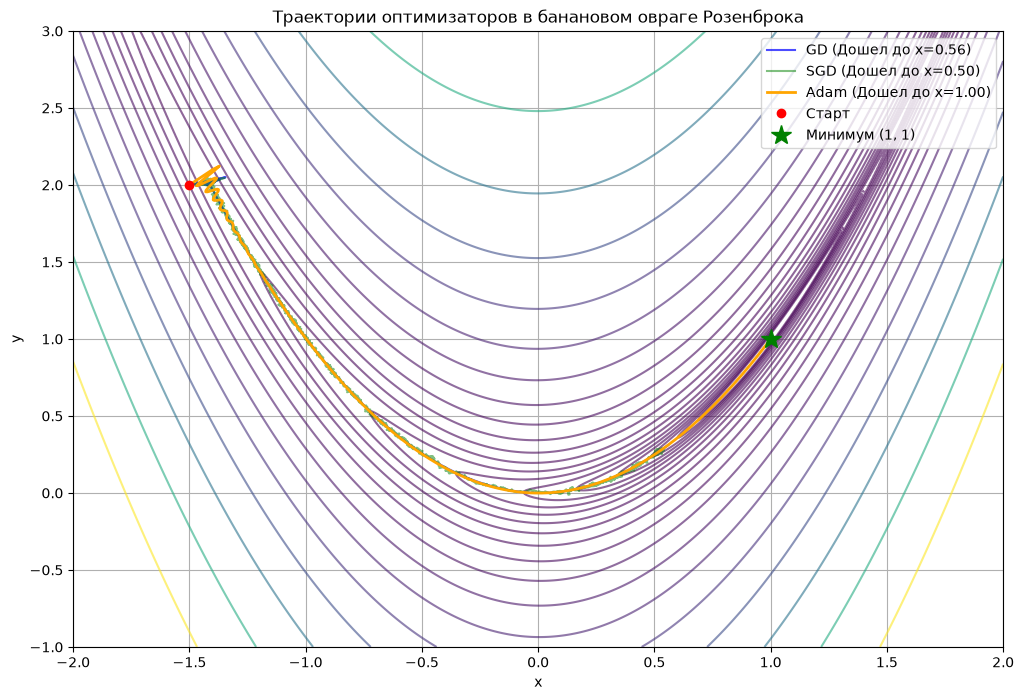

In [74]:
def rosenbrock(w):
    return (1.0 - w[0])**2 + 100.0 * (w[1] - w[0]**2)**2

def grad_rosenbrock(w):
    x, y = w[0], w[1]
    df_dx = -2.0 * (1.0 - x) - 400.0 * x * (y - x**2)
    df_dy = 200.0 * (y - x**2)
    return np.array([df_dx, df_dy])

start_point = [-1.5, 2.0]
steps = 2000

w_gd, path_gd = gd(grad_rosenbrock, start_point, lr=0.001, steps=steps)
w_sgd, path_sgd = sgd(grad_rosenbrock, start_point, lr=0.001, steps=steps)
w_adam, path_adam = adam(grad_rosenbrock, start_point, lr=0.1, steps=steps)

x = np.linspace(-2.0, 2.0, 500)
y = np.linspace(-1.0, 3.0, 500)
X, Y = np.meshgrid(x, y)
Z = (1.0 - X)**2 + 100.0 * (Y - X**2)**2

plt.figure(figsize=(12, 8))
plt.contour(X, Y, Z, levels=np.logspace(-1, 3, 20), cmap="viridis", alpha=0.6)

plt.plot(path_gd[:, 0], path_gd[:, 1], label=f'GD (Дошел до x={path_gd[-1,0]:.2f})', color='blue', alpha=0.7)
plt.plot(path_sgd[:, 0], path_sgd[:, 1], label=f'SGD (Дошел до x={path_sgd[-1,0]:.2f})', color='green', alpha=0.5)
plt.plot(path_adam[:, 0], path_adam[:, 1], label=f'Adam (Дошел до x={path_adam[-1,0]:.2f})', color='orange', linewidth=2)

plt.plot(start_point[0], start_point[1], 'ro', label='Старт')
plt.plot(1, 1, 'g*', markersize=15, label='Минимум (1, 1)')

plt.title('Траектории оптимизаторов в банановом овраге Розенброка')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

---
3. **Momentum руками.** Реализуйте `momentum_gd`. Покажите на овраге `f = x² + 100y²`, как момент гасит зигзаг.


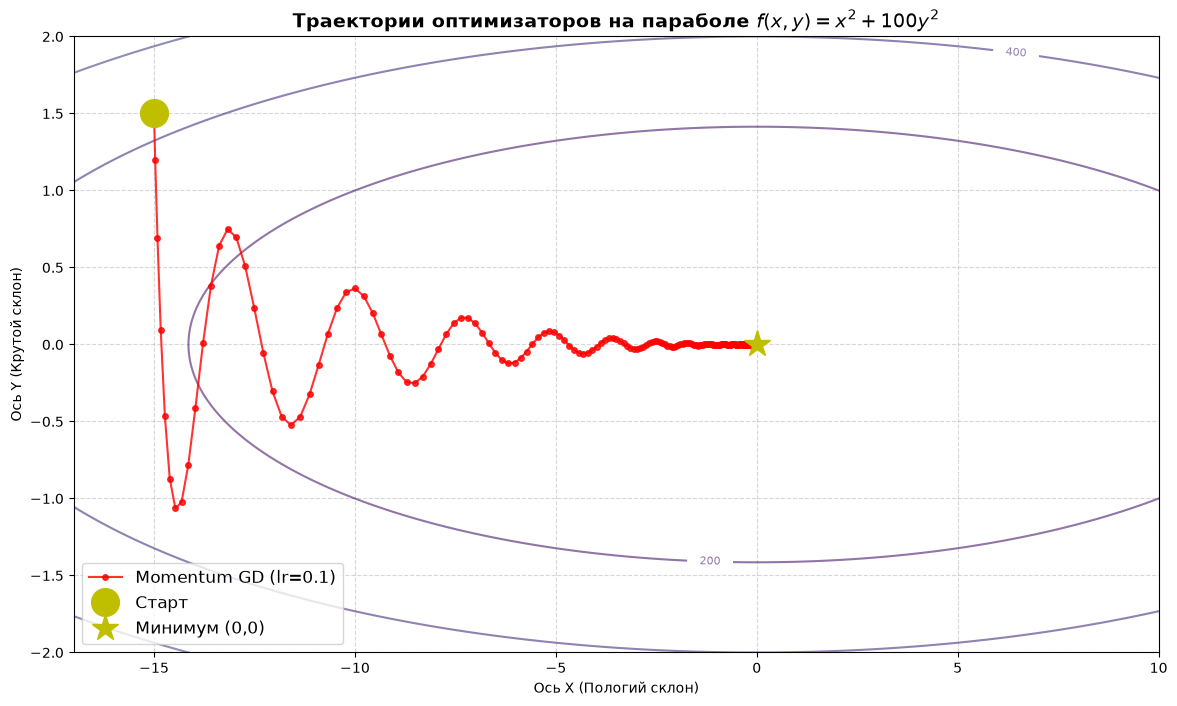

In [75]:
def L(w):
    return w[0] ** 2 + 100 * w[1] ** 2

def grad_f(w):
    return np.array([2.0 * w[0], 200.0 * w[1]])

def momentum_gd(grad, w0, lr=0.001, beta=0.9, steps=100):
    w = np.array(w0, dtype=float)
    v = np.zeros_like(w)
    history = [w.copy()]

    for _ in range(steps):
        v = beta * v + lr * grad(w)
        w = w - v
        history.append(w.copy())

    return w, np.array(history)

start_point = [-15.0, 1.5]
w_m, path_m = momentum_gd(grad=grad_f, w0=start_point, lr=0.001, beta=0.9, steps=200)
x = np.linspace(-20.0, 20.0, 500)
y = np.linspace(-5.0, 5.0, 500)
X, Y = np.meshgrid(x, y)
Z = X ** 2 + 100 * Y ** 2

plt.figure(figsize=(14, 8))
contours = plt.contour(X, Y, Z, levels=15, cmap='viridis', alpha=0.6)
plt.clabel(contours, inline=True, fontsize=8)

plt.plot(path_m[:, 0], path_m[:, 1], '-o', color='red', label='Momentum GD (lr=0.1)', markersize=4, alpha=0.8)

plt.plot(start_point[0], start_point[1], 'yo', markersize=20, label='Старт')
plt.plot(0, 0, 'y*', markersize=20, label='Минимум (0,0)')

plt.title('Траектории оптимизаторов на параболе $f(x, y) = x^2 + 100y^2$', fontsize=14, fontweight='bold')
plt.xlabel('Ось X (Пологий склон)')
plt.ylabel('Ось Y (Крутой склон)')
plt.xlim(-17, 10)
plt.ylim(-2, 2)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.show()


---
4. **RMSProp руками.** Реализуйте RMSProp. На функции, где градиенты сильно отличаются по координатам, покажите преимущество над GD.


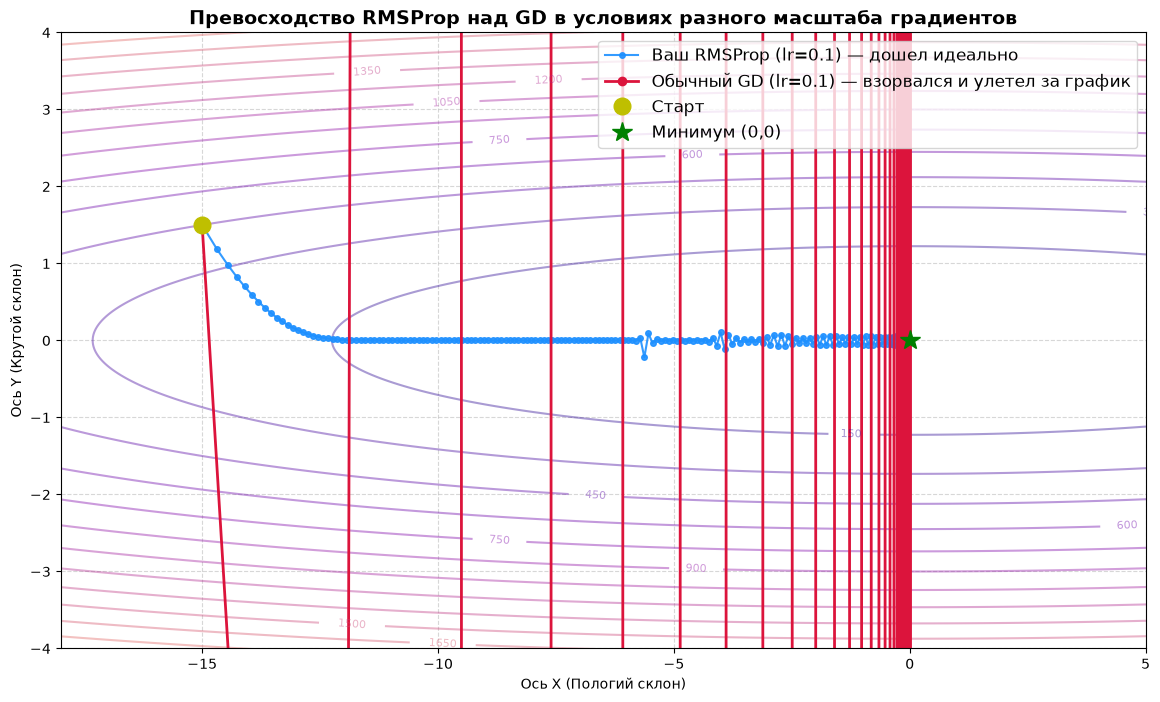

In [76]:
def L(w):
    return w[0] ** 2 + 100 * w[1] ** 2

def grad_f(w):
    return np.array([2.0 * w[0], 200.0 * w[1]])

def rmsprop(grad_f, w0, lr=0.1, beta=0.9, eps=1e-8, steps=100):
    w = np.array(w0, dtype=float)
    v = np.zeros_like(w)
    history = [w.copy()]

    for _ in range(steps):
        grad = grad_f(w)
        v = beta * v + (1 - beta) * (grad ** 2)
        w = w - (lr / (np.sqrt(v) + eps)) * grad
        history.append(w.copy())
    return w, np.array(history)

def vanilla_gd(grad_f, w0, lr=0.1, steps=100):
    w = np.array(w0, dtype=float)
    history = [w.copy()]
    for _ in range(steps):
        w = w - lr * grad_f(w)
        history.append(w.copy())
    return w, np.array(history)

start_point = [-15.0, 1.5]

w_rms, path_rms = rmsprop(grad_f, w0=start_point, lr=0.1, beta=0.9, steps=180)
w_gd, path_gd = vanilla_gd(grad_f, w0=start_point, lr=0.1, steps=50)

x = np.linspace(-20.0, 20.0, 500)
y = np.linspace(-5.0, 5.0, 500)
X, Y = np.meshgrid(x, y)
Z = X ** 2 + 100 * Y ** 2

plt.figure(figsize=(14, 8))
contours = plt.contour(X, Y, Z, levels=20, cmap='plasma', alpha=0.4)
plt.clabel(contours, inline=True, fontsize=8)

plt.plot(path_rms[:, 0], path_rms[:, 1], '-o', color='dodgerblue', 
         label='Ваш RMSProp (lr=0.1) — дошел идеально', markersize=4, alpha=0.9)
plt.plot(path_gd[:, 0], path_gd[:, 1], '-o', color='crimson', 
         label='Обычный GD (lr=0.1) — взорвался и улетел за график', linewidth=2, markersize=6)

plt.plot(start_point[0], start_point[1], 'yo', markersize=12, label='Старт')
plt.plot(0, 0, 'g*', markersize=15, label='Минимум (0,0)')

plt.title('Превосходство RMSProp над GD в условиях разного масштаба градиентов', fontsize=14, fontweight='bold')
plt.xlabel('Ось X (Пологий склон)')
plt.ylabel('Ось Y (Крутой склон)')
plt.xlim(-18, 5)
plt.ylim(-4, 4)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.show()


---
5. **Adam руками.** Реализуйте Adam полностью (с bias correction). Обучите им двухслойную сеть на MNIST. Достигните 97%+.


In [46]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

np.random.seed(42)

class AdamOptimizer:
    def __init__(self, weigths_dict, lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.t = 0 # Счетчик шагов для bias correction

        self.m = {k: np.zeros_like(v) for k, v in weigths_dict.items()}
        self.v = {k: np.zeros_like(v) for k, v in weigths_dict.items()}

    def step(self, weights, grads):
        self.t += 1

        for k in weights.keys():
            # 1. Скользящее среднее градиентов (первый момент)
            self.m[k] = self.beta1 * self.m[k] + (1 - self.beta1) * grads[k]
            
            # 2. Скользящее среднее квадратов градиентов (второй момент)
            self.v[k] = self.beta2 * self.v[k] + (1 - self.beta2) * (grads[k] ** 2)
            
            # 3. Bias correction (коррекция смещения к нулю на первых шагах)
            m_hat = self.m[k] / (1 - self.beta1 ** self.t)
            v_hat = self.v[k] / (1 - self.beta2 ** self.t)
            
            # 4. Обновление весов
            weights[k] -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)



# ДВУХСЛОЙНАЯ СЕТЬ (MLP) (784-128-10)
def init_weights(input_dim, hidden_dim, output_dim):
    # Инициализация Хе (He Initialization) для ReLU
    # Инициализация весов с учетом размерности слоя 
    # спасает нейроны от "взрыва" или 
    # "затухания" градиентов на старте.
    return {
        'W1': np.random.randn(input_dim, hidden_dim) * np.sqrt(2.0 / input_dim),
        'b1': np.zeros((1, hidden_dim)),
        'W2': np.random.randn(hidden_dim, output_dim) * np.sqrt(2.0 / hidden_dim),
        'b2': np.zeros((1, output_dim))
    }

def onehot(y, num_classes=10):
    return np.eye(num_classes)[y]

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def forward(X, weights):
    Z1 = np.dot(X, weights["W1"]) + weights["b1"]
    A1 = relu(Z1)
    Z2 = np.dot(A1, weights["W2"]) + weights["b2"]
    A2 = softmax(Z2)

    cache = {'X': X, 'Z1': Z1, 'A1': A1, 'Z2': Z2, 'A2': A2}
    return cache

def backward(cache, weights, y_oh):
    m = y_oh.shape[0]
    grads = {}

    # Градиент на выходном слое (с учетом Softmax + Cross-Entropy)
    dZ2 = cache["A2"] - y_oh
    dA1 = np.dot(dZ2, weights["W2"].T)
    dZ1 = dA1 * relu_derivative(cache["Z1"])

    grads["W1"] = np.dot(cache["X"].T, dZ1) / m
    grads["b1"] = np.sum(dZ1, axis=0, keepdims=True) / m
    grads["W2"] = np.dot(cache["A1"].T, dZ2) / m
    grads["b2"] = np.sum(dZ2, axis=0, keepdims=True) / m
    return grads


In [47]:
# ОБУЧЕНИЕ МОДЕЛИ
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist.data, mnist.target.astype(int)
X = X / 255.0 # масштабируем данные, чтобы экспоненты не ушли в бесконечность

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Архитектура двухслойной нейросети
# Вход: 784 пикселя -> Скрытый слой: 128 нейронов -> Выход: 10 классов
input_dim = 784
hidden_dim = 128
output_dim = 10
batch_size = 128
epochs = 10
lr = 0.001

In [48]:
weights = init_weights(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=output_dim)
optimizer = AdamOptimizer(weigths_dict=weights, lr=lr)

for epoch in range(epochs):
    permutation = np.random.permutation(X_train.shape[0])
    X_train_shuffled = X_train[permutation]
    y_train_shuffled = y_train[permutation]

    for i in range(0, X_train.shape[0], batch_size):
        X_batch = X_train_shuffled[i:i+batch_size, :]
        y_batch = y_train_shuffled[i:i+batch_size]

        y_batch_oh = onehot(y_batch)

        cache = forward(X_batch, weights)
        grads = backward(cache, weights, y_batch_oh)
        optimizer.step(weights, grads)

    test_probs = forward(X_test, weights)["A2"]
    test_preds = np.argmax(test_probs, axis=1)
    accuracy = np.mean(test_preds == y_test) * 100

    print(f"Эпоха {epoch+1}/{epochs} | Тестовая точность: {accuracy:.2f}%")
    if accuracy >= 97.0:
        print("Целевая точность в 97%+ успешно достигнута!")


Эпоха 1/10 | Тестовая точность: 93.69%
Эпоха 2/10 | Тестовая точность: 95.43%
Эпоха 3/10 | Тестовая точность: 96.12%
Эпоха 4/10 | Тестовая точность: 96.43%
Эпоха 5/10 | Тестовая точность: 96.88%
Эпоха 6/10 | Тестовая точность: 96.87%
Эпоха 7/10 | Тестовая точность: 97.21%
Целевая точность в 97%+ успешно достигнута!
Эпоха 8/10 | Тестовая точность: 97.09%
Целевая точность в 97%+ успешно достигнута!
Эпоха 9/10 | Тестовая точность: 97.26%
Целевая точность в 97%+ успешно достигнута!
Эпоха 10/10 | Тестовая точность: 97.29%
Целевая точность в 97%+ успешно достигнута!


---
6. **Эффект lr.** На MNIST с Adam запустите `lr = 1e-2, 1e-3, 1e-4, 1e-5`. Постройте кривые сходимости. Где работает быстрее? Где не сходится?


In [49]:
def train_model(lr_value, epochs=5, batch_size=256):
    np.random.seed(42)
    
    # Инициализация весов He
    weights = init_weights(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=output_dim)
    
    optimizer = AdamOptimizer(weights, lr=lr_value)
    history_acc = []
    
    for epoch in range(epochs):
        permutation = np.random.permutation(X_train.shape[0])
        X_train_shuffled = X_train[permutation]
        y_train_shuffled = y_train[permutation]

        for i in range(0, X_train.shape[0], batch_size):
            X_batch = X_train_shuffled[i:i+batch_size, :]
            y_batch = y_train_shuffled[i:i+batch_size]

            y_batch_oh = onehot(y_batch)

            cache = forward(X_batch, weights)
            grads = backward(cache, weights, y_batch_oh)
            optimizer.step(weights, grads)

        test_probs = forward(X_test, weights)["A2"] # получаем вероятности для каждой цифры
        test_preds = np.argmax(test_probs, axis=1) # берем самую большую вероятность
        accuracy = np.mean(test_preds == y_test) * 100
        history_acc.append(accuracy)
        
    return history_acc

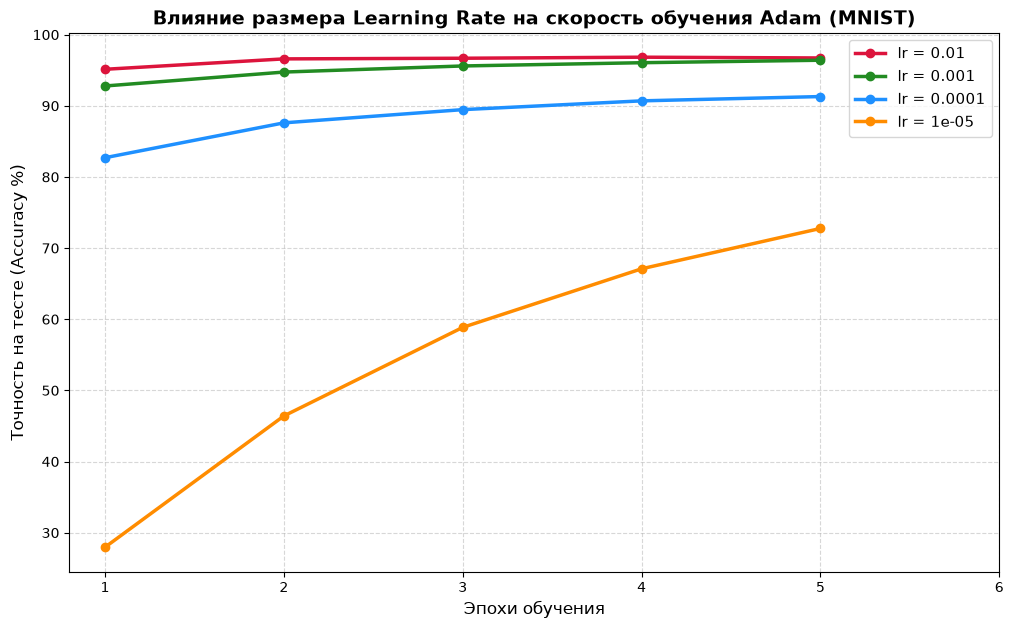

In [51]:
lr_val = [1e-2, 1e-3, 1e-4, 1e-5]
results = {}

for lr in lr_val:
    results[lr] = train_model(lr_value=lr)


plt.figure(figsize=(12, 7))
colors = {1e-2: 'crimson', 1e-3: 'forestgreen', 1e-4: 'dodgerblue', 1e-5: 'darkorange'}

for lr in lr_val:
    plt.plot(range(1, 6), results[lr], "-o", label=f'lr = {lr}', color=colors[lr], linewidth=2.5)

plt.title('Влияние размера Learning Rate на скорость обучения Adam (MNIST)', fontsize=14, fontweight='bold')
plt.xlabel('Эпохи обучения', fontsize=12)
plt.ylabel('Точность на тесте (Accuracy %)', fontsize=12)
plt.xticks(range(1, 7))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.show()

---
7. **Cosine annealing.** Реализуйте scheduler. Обучите модель: фиксированный lr vs cosine annealing. Сравните финальную точность.


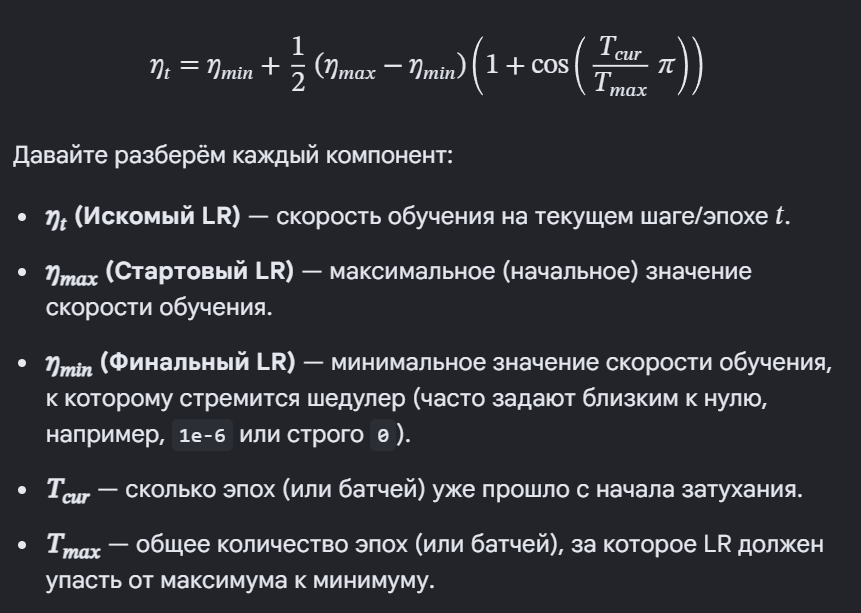

In [53]:
# Adam Optimizer с динамическим LR
class AdamOptimizer:
    def __init__(self, weigths_dict, beta1=0.9, beta2=0.999, eps=1e-8):
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.t = 0 # Счетчик шагов для bias correction

        self.m = {k: np.zeros_like(v) for k, v in weigths_dict.items()}
        self.v = {k: np.zeros_like(v) for k, v in weigths_dict.items()}

    def step(self, weights, grads, lr):
        self.t += 1

        for k in weights.keys():
            # 1. Скользящее среднее градиентов (первый момент)
            self.m[k] = self.beta1 * self.m[k] + (1 - self.beta1) * grads[k]
            
            # 2. Скользящее среднее квадратов градиентов (второй момент)
            self.v[k] = self.beta2 * self.v[k] + (1 - self.beta2) * (grads[k] ** 2)
            
            # 3. Bias correction (коррекция смещения к нулю на первых шагах)
            m_hat = self.m[k] / (1 - self.beta1 ** self.t)
            v_hat = self.v[k] / (1 - self.beta2 ** self.t)
            
            # 4. Обновление весов
            weights[k] -= lr * m_hat / (np.sqrt(v_hat) + self.eps)

# Реализация Cosine Annealing
class CosineAnnealingScheduler:
    def __init__(self, eta_max, eta_min, t_max):
        self.eta_max = eta_max
        self.eta_min = eta_min
        self.t_max = t_max
        self.t_cur = 0

    def get_lr(self):
        cos_inner = np.cos(np.pi * (self.t_cur / self.t_max))
        lr = self.eta_min + 0.5 * (self.eta_max - self.eta_min) * (1 + cos_inner)

        if self.t_cur < self.t_max:
            self.t_cur += 1

        return lr
        

def train_second_model(use_cos_ann_scheduler=False, epochs=5, batch_size=256):
    np.random.seed(42)
    
    # Инициализация весов He
    weights = init_weights(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=output_dim)
    
    optimizer = AdamOptimizer(weights)

    # Считаем общее число шагов (батчей) за всё обучение
    steps_per_epoch = int(np.ceil(X_train.shape[0] / batch_size))
    total_steps = steps_per_epoch * epochs

    scheduler = CosineAnnealingScheduler(eta_max=0.01, eta_min=0.0001, t_max=total_steps)

    history_acc = []
    history_lr = []
    
    for epoch in range(epochs):
        permutation = np.random.permutation(X_train.shape[0])
        X_train_shuffled = X_train[permutation]
        y_train_shuffled = y_train[permutation]

        for i in range(0, X_train.shape[0], batch_size):
            X_batch = X_train_shuffled[i:i+batch_size, :]
            y_batch = y_train_shuffled[i:i+batch_size]
            y_batch_oh = onehot(y_batch)

            if use_cos_ann_scheduler:
                cur_lr = scheduler.get_lr()
            else:
                cur_lr = 0.01 # фиксированный lr

            history_lr.append(cur_lr)

            cache = forward(X_batch, weights)
            grads = backward(cache, weights, y_batch_oh)
            optimizer.step(weights, grads, lr=cur_lr)

        test_probs = forward(X_test, weights)["A2"] # получаем вероятности для каждой цифры
        test_preds = np.argmax(test_probs, axis=1) # берем самую большую вероятность
        accuracy = np.mean(test_preds == y_test) * 100
        history_acc.append(accuracy)
        
    return np.array(history_acc), np.array(history_lr)

In [54]:
epochs = 7
acc_fixed, lr_fixed = train_second_model(use_cos_ann_scheduler=False, epochs=epochs)
acc_cosine, lr_cosine = train_second_model(use_cos_ann_scheduler=True, epochs=epochs)

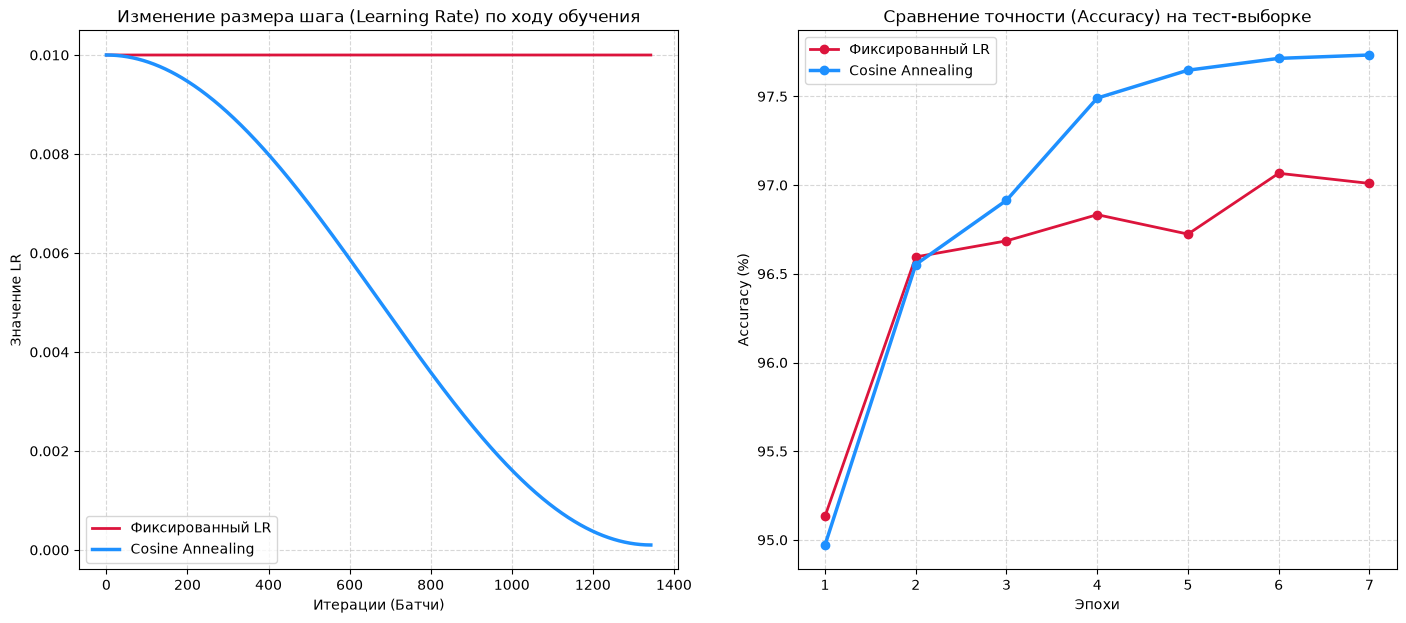

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 7))

# График изменения Learning Rate по итерациям
ax1.plot(lr_fixed, label='Фиксированный LR', color='crimson', linewidth=2)
ax1.plot(lr_cosine, label='Cosine Annealing', color='dodgerblue', linewidth=2.5)
ax1.set_title('Изменение размера шага (Learning Rate) по ходу обучения')
ax1.set_xlabel('Итерации (Батчи)')
ax1.set_ylabel('Значение LR')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()

# График роста точности
ax2.plot(range(1, epochs + 1), acc_fixed, '-o', label='Фиксированный LR', color='crimson', linewidth=2)
ax2.plot(range(1, epochs + 1), acc_cosine, '-o', label='Cosine Annealing', color='dodgerblue', linewidth=2.5)
ax2.set_title('Сравнение точности (Accuracy) на тест-выборке')
ax2.set_xlabel('Эпохи')
ax2.set_ylabel('Accuracy (%)')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend()

plt.show()

---
8. **Седловая точка.** На `f(x, y) = x² - y²` запустите GD из точки (0, ε). Покажите, что он застревает. Покажите, что Adam с шумом выходит.


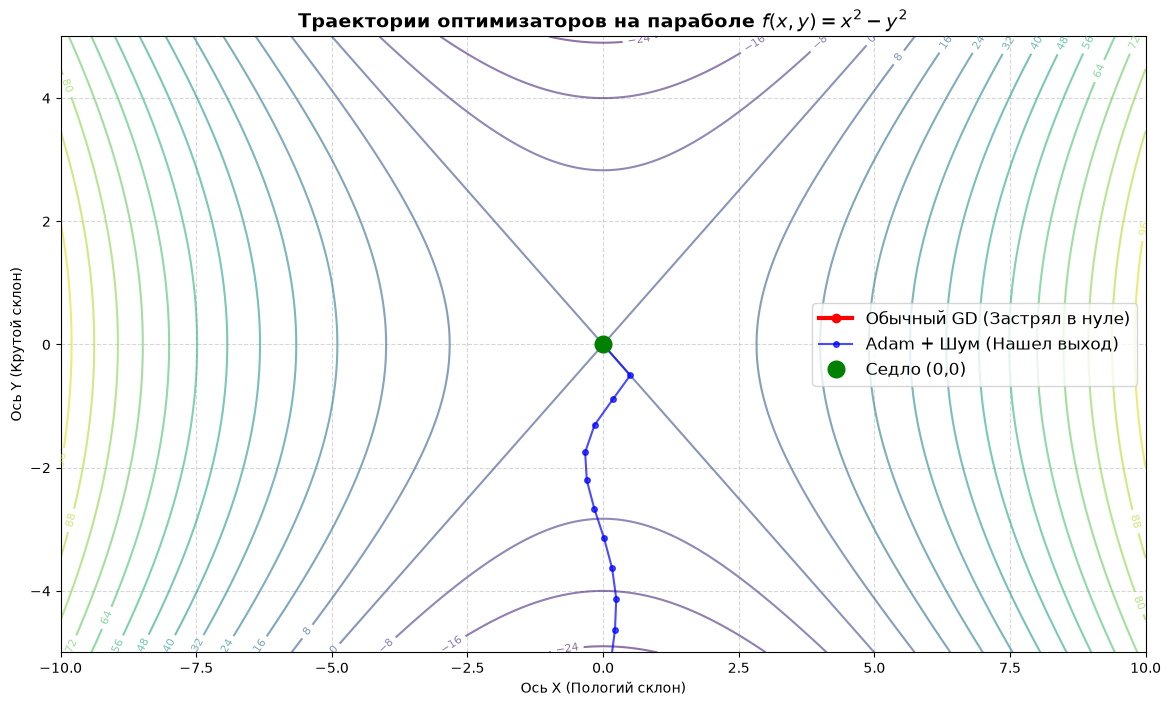

In [80]:
def L(w):
    return w[0] ** 2 - w[1] ** 2

def grad_f(w):
    return np.array([2.0 * w[0], -2.0 * w[1]])

def gd(grad, w0, lr=0.1, steps=1000):
    w = np.array(w0, dtype=float)
    history = [w.copy()]
    for _ in range(steps):
        w -= lr * grad(w)
        history.append(w.copy())

    return w, np.array(history)

def adam(grad, w0, lr=0.1, steps=1000, beta1=0.9, beta2=0.999, eps=1e-8):
    w = np.array(w0, dtype=float)
    m, v = np.zeros_like(w), np.zeros_like(w)
    history = [w.copy()]
    for t in range(1, steps):
        cur_grad = grad(w)
        noise = np.random.normal(0, 0.05, size=cur_grad.shape)
        total_grad = cur_grad + noise

        m = beta1 * m + (1.0 - beta1) * total_grad
        v = beta2 * v + (1.0 - beta2) * (total_grad ** 2)

        m_hat = m / (1.0 - beta1 ** t)
        v_hat = v / (1.0 - beta2 ** t)

        w -= (lr / (np.sqrt(v_hat) + eps)) * m_hat
        history.append(w.copy())
    return w, np.array(history)

eps = 0.0
start_point = [0.0, eps]

w_gd, path_gd = gd(grad=grad_f, w0=start_point, lr=0.008, steps=1000)
w_adam, path_adam = adam(grad=grad_f, w0=start_point, lr=0.5, steps=1000)

x = np.linspace(-10.0, 10.0, 500)
y = np.linspace(-5.0, 5.0, 500)
X, Y = np.meshgrid(x, y)
Z = X ** 2 - Y ** 2

plt.figure(figsize=(14, 8))
contours = plt.contour(X, Y, Z, levels=15, cmap='viridis', alpha=0.6)
plt.clabel(contours, inline=True, fontsize=8)

plt.plot(path_gd[:, 0], path_gd[:, 1], '-o', color='red', label='Обычный GD (Застрял в нуле)', linewidth=3)
plt.plot(path_adam[:, 0], path_adam[:, 1], '-o', color='blue', label='Adam + Шум (Нашел выход)', markersize=4, alpha=0.7)
plt.plot(start_point[0], start_point[1], 'go', markersize=12, label='Седло (0,0)')

plt.title('Траектории оптимизаторов на параболе $f(x, y) = x^2 - y^2$', fontsize=14, fontweight='bold')
plt.xlabel('Ось X (Пологий склон)')
plt.ylabel('Ось Y (Крутой склон)')
plt.xlim(-10, 10)
plt.ylim(-5, 5)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.show()

---
---
# Чек-лист по оптимизаторам и математике DL

---

### 1. Формулы GD, Momentum, RMSProp, Adam наизусть

Во всех формулах ниже: 
* θ — параметры модели
* η — learning rate
* $g_t$ — градиент лосса по параметрам на шаге t ($\nabla_{\theta} L(\theta_t)$)
* ε — малая константа против деления на ноль (обычно 10⁻⁸)

#### Gradient Descent (GD)
$$\theta_{t+1} = \theta_t - \eta \cdot g_t$$

#### Momentum
$$v_t = \beta \cdot v_{t-1} + (1 - \beta) \cdot g_t$$
$$\theta_{t+1} = \theta_t - \eta \cdot v_t$$
*(Примечание: существует альтернативная запись, где η вносится внутрь подсчета скорости $v_t$, суть метода от этого не меняется).*

#### RMSProp
$$s_t = \beta \cdot s_{t-1} + (1 - \beta) \cdot g_t^2$$
$$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{s_t} + \epsilon} \cdot g_t$$

#### Adam
$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$$
$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2$$
$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$
$$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \cdot \hat{m}_t$$

---

### 2. Реализация Adam с bias correction на 15 строк

Чистая лаконичная функция на Python/NumPy, выполняющая ровно один шаг оптимизации:

```python
import numpy as np

def adam_step(w, g, m, v, t, lr=0.001, b1=0.9, b2=0.999, eps=1e-8):
    # m, v — массивы состояний (инициализируются нулями на старте обучения)
    # t — номер текущей итерации, начиная с 1
    m = b1 * m + (1 - b1) * g
    v = b2 * v + (1 - b2) * (g ** 2)
    m_hat = m / (1 - b1 ** t)
    v_hat = v / (1 - b2 ** t)
    w = w - (lr / (np.sqrt(v_hat) + eps)) * m_hat
    return w, m, v
```

---

### 3. Понимание, зачем нужен learning rate schedule

Регулирование шага обучения (LR) необходимо по трем ключевым причинам:
1. **Быстрый старт**: В начале обучения веса инициализированы случайно. Большой LR помогает быстро покинуть неоптимальную зону и преодолеть локальные плато.
2. **Точная сходимость**: Ближе к концу обучения градиенты затухают. Большой шаг заставит модель хаотично «прыгать» вокруг минимума. Снижение LR позволяет аккуратно «скатиться» на самое дно функции потерь.
3. **Стабилизация лосса**: Использование расписаний (например, *Cosine Annealing* или *ReduceLROnPlateau*) страхует от взрыва градиентов и помогает выходить из резких локальных минимумов в пользу более пологих.

---

### 4. Отличие седла от минимума по гессиану

Когда первый градиент равен нулю ($\nabla L(\theta) = 0$), мы находимся в точке экстремума. Чтобы определить её тип, мы берем матрицу вторых производных — **Гессиан ($H$)** — и смотрим на её собственные значения ($\lambda$):

* **Локальный минимум**: Все собственные значения Гессиана строго больше нуля ($\lambda_i > 0$). Матрица положительно определена ($H > 0$). По всем направлениям функция только растет (форма «чаши»).
* **Седловая точка**: Присутствуют как положительные, так и отрицательные собственные значения ($\lambda_{min} < 0 < \lambda_{max}$). Матрица знаконеопределенная. По одним направлениям функция растет, а по другим — убывает.
* *(Для справки — Локальный максимум: Все $\lambda_i < 0$, матрица отрицательно определена).*

---

### 5. Выбор подходящего оптимизатора под задачу

* **Adam / AdamW**: *Выбор по умолчанию*. Идеален для Transformers, NLP, GAN и глубоких плотных сетей. Отлично справляется с разреженными градиентами и не требует долгой ручной настройки LR. (AdamW обязателен, если используется L2-регуляризация).
* **SGD с Momentum**: *Стандарт для Computer Vision* (ResNet, ConvNets). При правильном расписании LR дает лучшую обобщающую способность (generalization), чем Adam, сглаживая шум в данных и не застревая в субоптимальных острых минимумах.
* **RMSProp**: Хорошо показывает себя в *Reinforcement Learning* (обучении с подкреплением) и рекуррентных сетях (RNN/LSTM), так как эффективно работает в условиях нестационарных и быстро меняющихся целей.
